# MedXAI — Notebook 01 : Pipeline ACF+Anchor
## Implémentation fidèle au PFE UMMTO 2022

**Pipeline complet en 5 étapes :**
1. Transformation des données multi-label en contexte formel (KOMR)
2. Extraction des concepts formels via algorithme Chein
3. Réduction des concepts formels 
4. Calcul des DAS — Ensembles d'Attributs Décisifs 
5. Génération des règles Anchor avec couverture

**Dataset :** 480 patients · 29 symptômes · 4 maladies respiratoires

In [1]:
# ============================================================
# IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath('..'))
from src.acf_das import FormalContext
from src.anchor_rules import generate_rules, save_rules

pd.set_option('display.max_colwidth', None)
print("Imports OK")

Imports OK


In [2]:

# CHARGEMENT ET FILTRAGE DU DATASET


df = pd.read_csv('data/dataset.csv')
maladies = ['Bronchial Asthma', 'Tuberculosis', 'Pneumonia', 'Common Cold']
df_resp = df[df['Disease'].isin(maladies)].reset_index(drop=True)

print(f"Dataset complet : {len(df)} patients")
print(f"Dataset respiratoire : {len(df_resp)} patients")
print(f"\nDistribution :")
print(df_resp['Disease'].value_counts())

Dataset complet : 4920 patients
Dataset respiratoire : 480 patients

Distribution :
Disease
Bronchial Asthma    120
Tuberculosis        120
Common Cold         120
Pneumonia           120
Name: count, dtype: int64


## Étape 1 — Transformation multi-label en contexte formel (KOMR)

Les données 3D (Patient × Symptôme × Maladie) sont transformées en matrice 2D KOMR (Patient × Maladie-Symptôme).

**Règle :** `KOMR[patient][maladie_symptôme] = 1` si le patient a le symptôme ET est diagnostiqué avec la maladie.

In [3]:

# ÉTAPE 1 — CONSTRUCTION DU CONTEXTE FORMEL KOMR

fc = FormalContext(df_resp)
KOMR = fc.build_context()

print(f"\nAperçu KOMR — Patient 1 (Bronchial Asthma) :")
row = KOMR.iloc[0]
cols_a_1 = [col for col in KOMR.columns if row[col] == 1]
for col in cols_a_1:
    print(f"  ✓ {col}")

Étape 1 — Transformation multi-label → contexte formel...
Contexte formel KOMR construit :
   480 patients
   4 maladies
   29 symptômes
   116 colonnes (Maladie_Symptôme)

Aperçu KOMR — Patient 1 (Bronchial Asthma) :
  ✓ Bronchial Asthma_breathlessness
  ✓ Bronchial Asthma_cough
  ✓ Bronchial Asthma_family_history
  ✓ Bronchial Asthma_fatigue
  ✓ Bronchial Asthma_high_fever
  ✓ Bronchial Asthma_mucoid_sputum


## Étape 2 — Extraction des concepts formels (Algorithme Chein)

L'algorithme Chein génère les concepts formels par niveaux :
- **L1** : un rectangle par patient
- **L(p+1)** : union des extensions × intersection des intensions
- Stop quand L(p+1) est vide

In [4]:

# ÉTAPE 2 — EXTRACTION DES CONCEPTS FORMELS

concepts_bruts = fc.extract_concepts()

print(f"\nExemple — 3 premiers concepts :")
for i, (ext, inten) in enumerate(concepts_bruts[:3]):
    print(f"\nConcept {i+1} :")
    print(f"  Patients ({len(ext)}) : {sorted(ext)[:5]}...")
    print(f"  Attributs : {sorted(inten)[:3]}...")


Étape 2 — Extraction concepts formels (algorithme Chein)...
   Niveau L1 : 480 rectangles
   Niveau L2 : 133 rectangles
   Niveau L3 : 542 rectangles
   Niveau L4 : 797 rectangles
   Niveau L5 : 698 rectangles
   Niveau L6 : 510 rectangles
   Niveau L7 : 285 rectangles
   Niveau L8 : 111 rectangles
   Niveau L9 : 27 rectangles
   Niveau L10 : 3 rectangles
831 concepts formels extraits

Exemple — 3 premiers concepts :

Concept 1 :
  Patients (72) : [0, 7, 40, 47, 80]...
  Attributs : ['Bronchial Asthma_breathlessness', 'Bronchial Asthma_cough', 'Bronchial Asthma_family_history']...

Concept 2 :
  Patients (72) : [10, 11, 50, 51, 90]...
  Attributs : ['Tuberculosis_blood_in_sputum', 'Tuberculosis_breathlessness', 'Tuberculosis_chest_pain']...

Concept 3 :
  Patients (72) : [20, 21, 60, 61, 100]...
  Attributs : ['Common Cold_chest_pain', 'Common Cold_chills', 'Common Cold_congestion']...


## Étape 3 — Réduction des concepts formels (Algorithme 3)

On supprime les concepts redondants selon 3 conditions :
1. Même intension (maladie)
2. Extension de CF2 ⊆ Extension de CF1
3. Condition de CF2 ⊇ Condition de CF1

In [5]:

# ÉTAPE 3 — RÉDUCTION DES CONCEPTS FORMELS

concepts_reduits = fc.reduce_concepts()

print(f"\nLes {len(concepts_reduits)} concepts formels réduits :\n")
for i, (ext, inten) in enumerate(concepts_reduits):
    # Extraire maladie et symptômes
    maladie = None
    symptomes = []
    for col in inten:
        for d in maladies:
            if col.startswith(f"{d}_"):
                maladie = d
                symptomes.append(col.replace(f"{d}_", "").strip())
    
    print(f"Concept {i+1} — {maladie} :")
    print(f" {len(ext)} patients")
    print(f" Symptômes : {sorted(symptomes)}")


Étape 3 — Nettoyage des concepts formels...
   Concepts avant nettoyage : 831
   Concepts après nettoyage : 9
 Nettoyage terminé

Les 9 concepts formels réduits :

Concept 1 — Bronchial Asthma :
 114 patients
 Symptômes : ['mucoid_sputum']
Concept 2 — Bronchial Asthma :
 114 patients
 Symptômes : ['family_history']
Concept 3 — Bronchial Asthma :
 114 patients
 Symptômes : ['breathlessness']
Concept 4 — Bronchial Asthma :
 114 patients
 Symptômes : ['high_fever']
Concept 5 — Bronchial Asthma :
 108 patients
 Symptômes : ['cough']
Concept 6 — Bronchial Asthma :
 108 patients
 Symptômes : ['fatigue']
Concept 7 — Tuberculosis :
 120 patients
 Symptômes : ['blood_in_sputum', 'chest_pain', 'loss_of_appetite', 'malaise', 'mild_fever', 'phlegm', 'swelled_lymph_nodes', 'yellowing_of_eyes']
Concept 8 — Common Cold :
 120 patients
 Symptômes : ['chest_pain', 'congestion', 'loss_of_smell', 'muscle_pain', 'phlegm', 'redness_of_eyes', 'runny_nose', 'sinus_pressure', 'throat_irritation']
Concept 9 —

## Étape 4 — Calcul des DAS 

Pour chaque maladie, on calcule les Ensembles d'Attributs Décisifs (DAS)
à partir des concepts formels réduits.

**DAS** = plus petit sous-ensemble de symptômes qui caractérise une maladie.

In [6]:

# ÉTAPE 4 — CALCUL DES DAS

das_dict = {}
for disease in maladies:
    das_dict[disease] = fc.compute_das(disease)

print("Ensemble des DAS par maladie :\n")
for disease, das_list in das_dict.items():
    print(f"--- {disease} ---")
    for i, das in enumerate(das_list):
        print(f"  DAS {i+1} : {das}")
    print()

Ensemble des DAS par maladie :

--- Bronchial Asthma ---
  DAS 1 : ['breathlessness', 'cough', 'family_history', 'high_fever', 'mucoid_sputum']
  DAS 2 : ['breathlessness', 'family_history', 'fatigue', 'high_fever', 'mucoid_sputum']
  DAS 3 : ['breathlessness', 'cough', 'family_history', 'fatigue', 'mucoid_sputum']
  DAS 4 : ['cough', 'family_history', 'fatigue', 'high_fever', 'mucoid_sputum']
  DAS 5 : ['breathlessness', 'cough', 'fatigue', 'high_fever', 'mucoid_sputum']
  DAS 6 : ['breathlessness', 'cough', 'family_history', 'fatigue', 'high_fever']

--- Tuberculosis ---
  DAS 1 : ['blood_in_sputum', 'chest_pain', 'loss_of_appetite', 'malaise', 'mild_fever', 'phlegm', 'swelled_lymph_nodes', 'yellowing_of_eyes']

--- Pneumonia ---
  DAS 1 : ['chest_pain', 'fast_heart_rate', 'rusty_sputum']

--- Common Cold ---
  DAS 1 : ['chest_pain', 'congestion', 'loss_of_smell', 'muscle_pain', 'phlegm', 'redness_of_eyes', 'runny_nose', 'sinus_pressure', 'throat_irritation']



## Étape 5 — Génération des règles Anchor

Chaque DAS est transformé en règle lisible avec sa couverture :

**Format :** `IF symptôme(s) THEN maladie — Couverture = X`

**Couverture** = proportion de patients de la maladie couverts par la règle.

In [8]:

# ÉTAPE 5 — GÉNÉRATION DES RÈGLES ANCHOR

# Construire la matrice binaire simple pour le calcul de couverture
symptom_cols = [c for c in df_resp.columns if c.startswith('Symptom_')]
all_symptoms = set()
for col in symptom_cols:
    all_symptoms.update(df_resp[col].dropna().unique())
symptoms = sorted([s.strip() for s in all_symptoms])

bm = pd.DataFrame(0, index=range(len(df_resp)), columns=symptoms)
for idx, row in df_resp.iterrows():
    for col in symptom_cols:
        if pd.notna(row[col]):
            bm.loc[idx, row[col].strip()] = 1
bm['Disease'] = df_resp['Disease'].values

# Générer les règles
df_rules = generate_rules(das_dict, bm)
save_rules(df_rules, 'results/rules/anchor_rules_v2.csv')

print("\n Résumé des règles générées :")
print(df_rules[['Maladie', 'Règle', 'Couverture']].to_string(index=False))

Étape 5 — Génération des règles Anchor...

--- Bronchial Asthma ---
  R1: IF breathlessness AND cough AND family_history AND high_fever AND mucoid_sputum THEN Bronchial Asthma
       Couverture = 0.7
  R2: IF breathlessness AND family_history AND fatigue AND high_fever AND mucoid_sputum THEN Bronchial Asthma
       Couverture = 0.7
  R3: IF breathlessness AND cough AND family_history AND fatigue AND mucoid_sputum THEN Bronchial Asthma
       Couverture = 0.65
  R4: IF cough AND family_history AND fatigue AND high_fever AND mucoid_sputum THEN Bronchial Asthma
       Couverture = 0.65
  R5: IF breathlessness AND cough AND fatigue AND high_fever AND mucoid_sputum THEN Bronchial Asthma
       Couverture = 0.65
  R6: IF breathlessness AND cough AND family_history AND fatigue AND high_fever THEN Bronchial Asthma
       Couverture = 0.65
--- Tuberculosis ---
  R1: IF blood_in_sputum AND chest_pain AND loss_of_appetite AND malaise AND mild_fever AND phlegm AND swelled_lymph_nodes AND yellowing

## Visualisation des règles Anchor

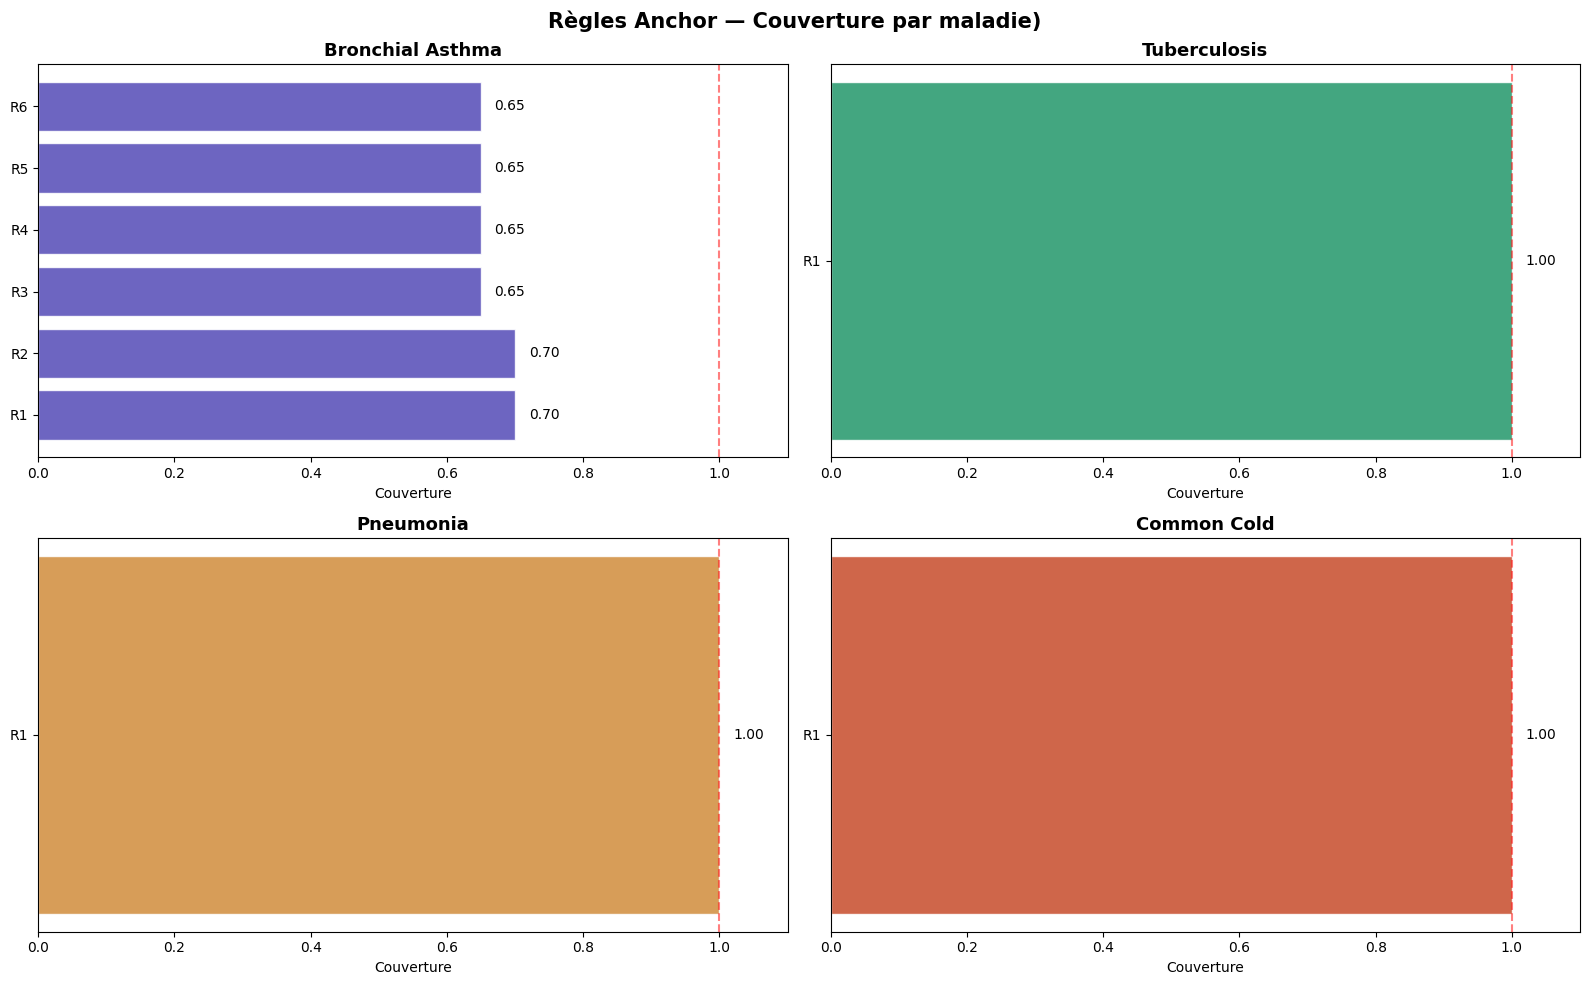

Graphique sauvegardé


In [12]:

# VISUALISATION DES RÈGLES ANCHOR

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

colors = {
    'Bronchial Asthma': '#534AB7',
    'Tuberculosis': '#22976A',
    'Pneumonia': '#D08C3B',
    'Common Cold': '#C74B2A'
}

for i, disease in enumerate(maladies):
    subset = df_rules[df_rules['Maladie'] == disease].copy()
    labels = [f"R{j+1}" for j in range(len(subset))]

    axes[i].barh(
        labels,
        subset['Couverture'].values,
        color=colors[disease],
        alpha=0.85,
        edgecolor='white'
    )
    axes[i].set_title(f'{disease}', fontsize=13, fontweight='bold')
    axes[i].set_xlim(0, 1.1)
    axes[i].set_xlabel('Couverture')
    axes[i].axvline(x=1.0, color='red', linestyle='--', alpha=0.5)

    # Annoter chaque barre avec la couverture
    for j, (val, label) in enumerate(zip(subset['Couverture'].values, labels)):
        axes[i].text(val + 0.02, j, f'{val:.2f}', va='center', fontsize=10)

plt.suptitle('Règles Anchor — Couverture par maladie)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/anchor_rules_v2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé")

## 6. Classifieur XGBoost + Explicabilité SHAP
Comparaison avec une approche standard de ML interprétable.

In [14]:

# PRÉPARATION DES DONNÉES POUR XGBOOST
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import xgboost as xgb
import shap

# Utiliser la matrice binaire déjà construite
X = bm.drop(columns=['Disease'])
y = bm['Disease']

# Encoder les labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train : {X_train.shape[0]} patients")
print(f"Test  : {X_test.shape[0]} patients")
print(f"Classes : {le.classes_}")

Train : 384 patients
Test  : 96 patients
Classes : ['Bronchial Asthma' 'Common Cold' 'Pneumonia' 'Tuberculosis']


In [15]:
# ============================================================
# ENTRAÎNEMENT XGBOOST
# ============================================================

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0
)

model.fit(X_train, y_train)

# Évaluation
y_pred = model.predict(X_test)
print("Rapport de classification :\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Rapport de classification :

                  precision    recall  f1-score   support

Bronchial Asthma       1.00      1.00      1.00        24
     Common Cold       1.00      1.00      1.00        24
       Pneumonia       1.00      1.00      1.00        24
    Tuberculosis       1.00      1.00      1.00        24

        accuracy                           1.00        96
       macro avg       1.00      1.00      1.00        96
    weighted avg       1.00      1.00      1.00        96



<Figure size 1000x800 with 0 Axes>

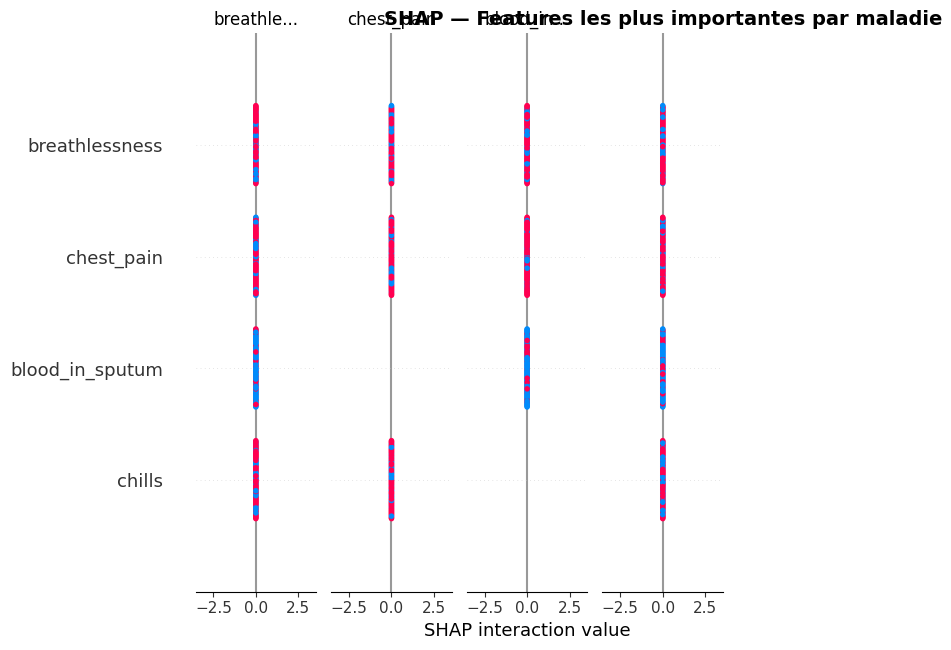

In [16]:
# ============================================================
# EXPLICABILITÉ SHAP
# ============================================================

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Visualisation 1 : Summary plot — features les plus importantes
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test,
    class_names=le.classes_,
    show=False
)
plt.title('SHAP — Features les plus importantes par maladie', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results/figures/shap_summary.png', dpi=150, bbox_inches='tight')


## 7. Comparaison ACF+Anchor vs SHAP
Confrontation des deux approches d'explicabilité :
- **ACF+Anchor** : règles logiques extraites par analyse de concepts formels
- **SHAP** : importance des features par contribution marginale

In [18]:
# ============================================================
# COMPARAISON ACF+ANCHOR vs SHAP
# ============================================================

print("=" * 60)
print("COMPARAISON ACF+Anchor vs SHAP par maladie")
print("=" * 60)

for i, disease in enumerate(le.classes_):
    print(f"\n--- {disease} ---")
    
    # SHAP top 5 features
    shap_imp = pd.Series(
        np.abs(shap_values[:, :, i]).mean(axis=0),
        index=X_test.columns
    ).sort_values(ascending=False).head(5)
    
    print("  SHAP top 5 features :")
    for feat, val in shap_imp.items():
        print(f"    {feat.strip()} : {val:.3f}")
    
    # ACF DAS — affichage corrigé
    disease_key = [k for k in das_dict.keys() if k == disease]
    if disease_key:
        das_list = das_dict[disease_key[0]]
        print(f"  ACF DAS ({len(das_list)} ensembles) :")
        for j, das in enumerate(das_list):
            print(f"    DAS {j+1} : {das}")

print("\n Comparaison terminée")

COMPARAISON ACF+Anchor vs SHAP par maladie

--- Bronchial Asthma ---
  SHAP top 5 features :
    chest_pain : 3.002
    blood_in_sputum : 0.000
    breathlessness : 0.000
    chills : 0.000
    congestion : 0.000
  ACF DAS (6 ensembles) :
    DAS 1 : ['breathlessness', 'cough', 'family_history', 'high_fever', 'mucoid_sputum']
    DAS 2 : ['breathlessness', 'family_history', 'fatigue', 'high_fever', 'mucoid_sputum']
    DAS 3 : ['breathlessness', 'cough', 'family_history', 'fatigue', 'mucoid_sputum']
    DAS 4 : ['cough', 'family_history', 'fatigue', 'high_fever', 'mucoid_sputum']
    DAS 5 : ['breathlessness', 'cough', 'fatigue', 'high_fever', 'mucoid_sputum']
    DAS 6 : ['breathlessness', 'cough', 'family_history', 'fatigue', 'high_fever']

--- Common Cold ---
  SHAP top 5 features :
    congestion : 3.002
    blood_in_sputum : 0.000
    breathlessness : 0.000
    chest_pain : 0.000
    chills : 0.000
  ACF DAS (1 ensembles) :
    DAS 1 : ['chest_pain', 'congestion', 'loss_of_smell',

## 8. Conclusion

Ce notebook présente une approche d'explicabilité basée sur l'Analyse de Concepts Formels (ACF) appliquée à la classification de maladies respiratoires.

**Ce qu'on a fait :**
- Construit un contexte formel à partir de 480 patients et 29 symptômes
- Extrait les attributs décisifs (DAS) pour 4 maladies respiratoires
- Généré les règles Anchor interprétables avec leur couverture
- Comparé avec l'approche SHAP standard

**Résultat clé :** Les deux méthodes identifient des features importantes différentes,
ce qui montre l'intérêt d'une approche complémentaire comme ACF+Anchor.

